In [3]:
import json

with open("data/final_2loom_dataset.json") as f:
    content = f.read()

# Fix format
content = content.replace("},\n", "}\n")  # remove trailing commas

data = []
for line in content.split("\n"):
    line = line.strip()
    if line:
        try:
            data.append(json.loads(line))
        except:
            pass

print("Loaded:", len(data))

Loaded: 518400


In [4]:
import pandas as pd

df = pd.json_normalize(data)

# Convert timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])

df.head()

,device_id,timestamp,machine.status,machine.speed,machine.cycles,machine.saree_count,environment.temperature,environment.humidity,environment.vibration,fault.thread_break,...,energy.current,energy.power,control.target_speed,control.speed_error,control.mode,production.defect_rate,production.quality,production.efficiency,fault_detail.cause,fault_detail.severity
0,loom_01,2026-01-01 00:00:00+00:00,ON,134,1,0,32.31,66.92,0.0646,False,...,3.733,814.66,139,-5,AUTO,0.0358,B,0.964,None,none
1,loom_02,2026-01-01 00:00:00+00:00,OFF,0,0,0,32.77,67.78,0.0098,False,...,0.200,44.00,0,0,OFF,0.0000,N/A,0.000,None,none
2,loom_01,2026-01-01 00:00:10+00:00,ON,134,2,0,32.47,69.08,0.0301,False,...,3.733,814.66,139,-5,AUTO,0.0158,A,0.964,None,none
3,loom_02,2026-01-01 00:00:10+00:00,OFF,0,0,0,32.75,69.12,0.0100,False,...,0.200,44.00,0,0,OFF,0.0000,N/A,0.000,None,none
4,loom_01,2026-01-01 00:00:20+00:00,ON,134,3,0,31.62,67.28,0.0465,False,...,3.733,814.66,139,-5,AUTO,0.0254,B,0.964,None,none


In [5]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

df.describe()

Shape: (518400, 30)

Columns:
 Index(['device_id', 'timestamp', 'machine.status', 'machine.speed',
       'machine.cycles', 'machine.saree_count', 'environment.temperature',
       'environment.humidity', 'environment.vibration', 'fault.thread_break',
       'fault.overheat', 'fault.motor_fault', 'fault.anomaly_score',
       'process.pattern_id', 'process.pattern_matrix',
       'process.thread_position', 'process.weft_insertions',
       'thread.warp_tension', 'thread.weft_tension', 'energy.voltage',
       'energy.current', 'energy.power', 'control.target_speed',
       'control.speed_error', 'control.mode', 'production.defect_rate',
       'production.quality', 'production.efficiency', 'fault_detail.cause',
       'fault_detail.severity'],
      dtype='object')


,machine.speed,machine.cycles,machine.saree_count,environment.temperature,environment.humidity,environment.vibration,fault.anomaly_score,process.thread_position,process.weft_insertions,thread.warp_tension,thread.weft_tension,energy.voltage,energy.current,energy.power,control.target_speed,control.speed_error,production.defect_rate,production.efficiency
count,518400.000000,518400.000000,518400.000000,518400.000000,518344.000000,518400.000000,518400.000000,518400.000000,518400.000000,518400.000000,518400.000000,518400.000000,518400.000000,518400.000000,518400.000000,518400.000000,518400.000000,518400.000000
mean,101.757459,115822.350347,74.532297,37.088256,66.905881,0.093160,0.093996,0.892361,3.421238,5.553536,5.380111,218.638809,3.061336,668.769513,106.062272,-4.303054,0.047048,0.853900
std,40.738451,66779.667833,45.061164,4.616936,10.748769,0.093686,0.065321,0.831241,1.388175,2.200036,2.276579,0.542994,1.048694,228.705319,42.233894,2.509907,0.052105,0.296838
min,0.000000,0.000000,0.000000,25.970000,42.370000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,216.430000,0.200000,44.000000,0.000000,-32.000000,0.000000,0.000000
25%,89.000000,58026.750000,36.000000,33.430000,58.810000,0.056700,0.045800,0.000000,3.000000,5.542000,5.243000,218.250000,2.986000,653.387500,94.000000,-5.000000,0.025900,0.946800
50%,110.000000,115830.500000,71.000000,37.170000,66.960000,0.088800,0.088000,1.000000,4.000000,6.047000,5.817000,218.530000,3.333000,728.440000,114.000000,-5.000000,0.043900,0.956500
75%,130.000000,173676.250000,112.000000,40.090000,74.090000,0.116500,0.128000,2.000000,4.000000,6.495000,6.326000,218.810000,3.683000,803.900000,135.000000,-5.000000,0.060700,0.963200
max,268.000000,232560.000000,164.000000,75.360000,98.000000,2.630100,0.916900,2.000000,9.000000,36.504000,43.894000,220.000000,5.967000,1291.350000,273.000000,20.000000,0.990000,1.000000


In [7]:
df_resampled = df.set_index("timestamp").resample("1min").mean(numeric_only=True).reset_index()

In [8]:
loom1 = df_sample[df_sample["device_id"] == "loom_01"]
loom2 = df_sample[df_sample["device_id"] == "loom_02"]

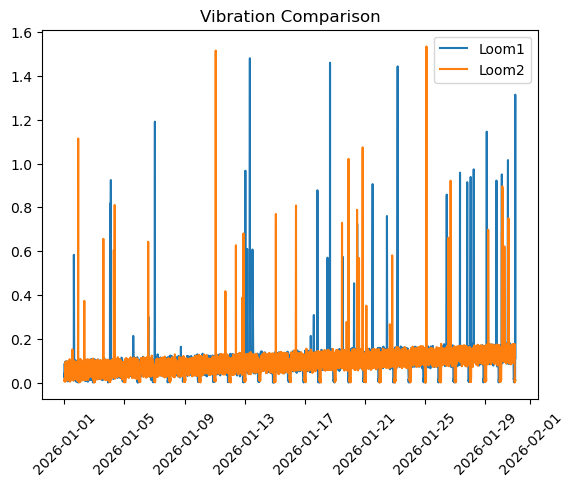

In [9]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(loom1["timestamp"], loom1["environment.vibration"], label="Loom1")
plt.plot(loom2["timestamp"], loom2["environment.vibration"], label="Loom2")
plt.title("Vibration Comparison")
plt.legend()
plt.xticks(rotation=45)
plt.show()

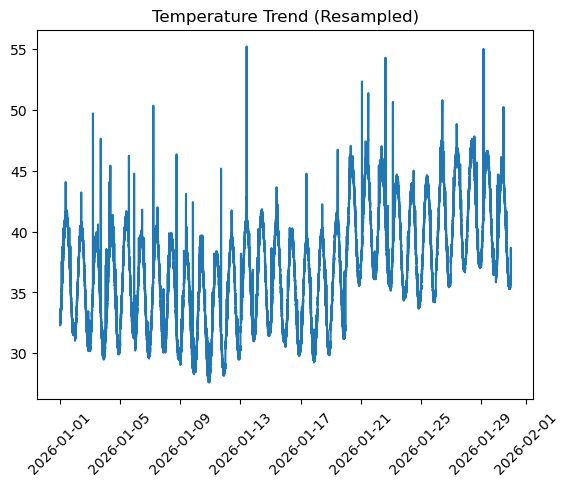

In [10]:
plt.figure()
plt.plot(df_resampled["timestamp"], df_resampled["environment.temperature"])
plt.title("Temperature Trend (Resampled)")
plt.xticks(rotation=45)
plt.show()

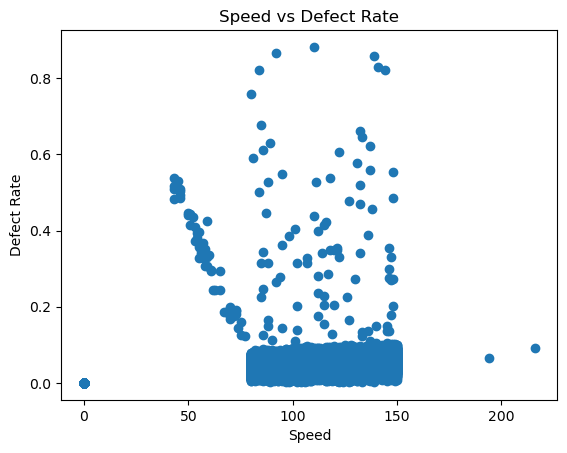

In [11]:
plt.figure()
plt.scatter(df_sample["machine.speed"], df_sample["production.defect_rate"])
plt.title("Speed vs Defect Rate")
plt.xlabel("Speed")
plt.ylabel("Defect Rate")
plt.show()

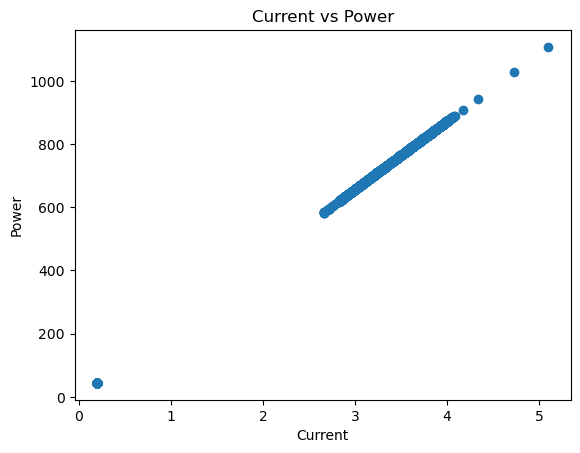

In [12]:
plt.figure()
plt.scatter(df_sample["energy.current"], df_sample["energy.power"])
plt.title("Current vs Power")
plt.xlabel("Current")
plt.ylabel("Power")
plt.show()

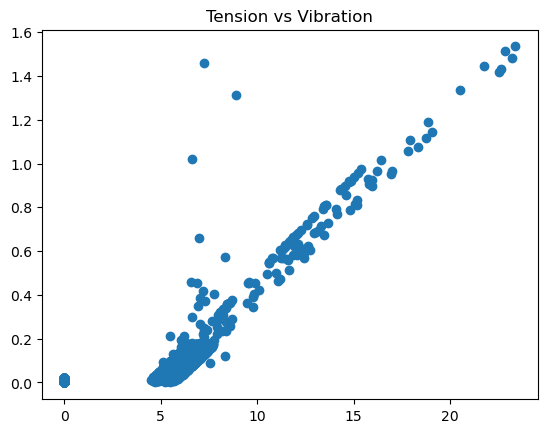

In [13]:
plt.figure()
plt.scatter(df_sample["thread.warp_tension"], df_sample["environment.vibration"])
plt.title("Tension vs Vibration")
plt.show()

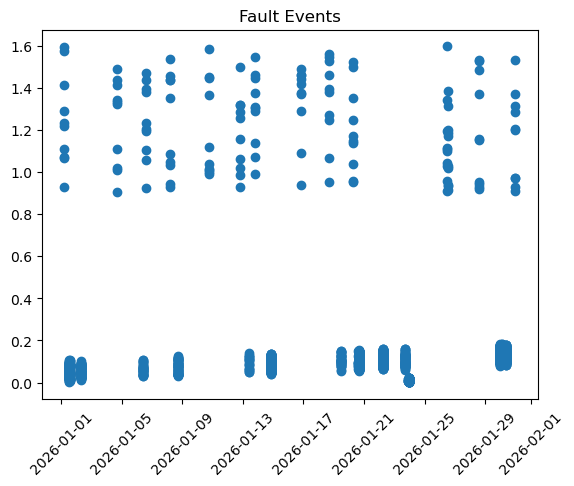

In [14]:
faults = df[df["fault.thread_break"] == True]

plt.figure()
plt.scatter(faults["timestamp"], faults["environment.vibration"])
plt.title("Fault Events")
plt.xticks(rotation=45)
plt.show()

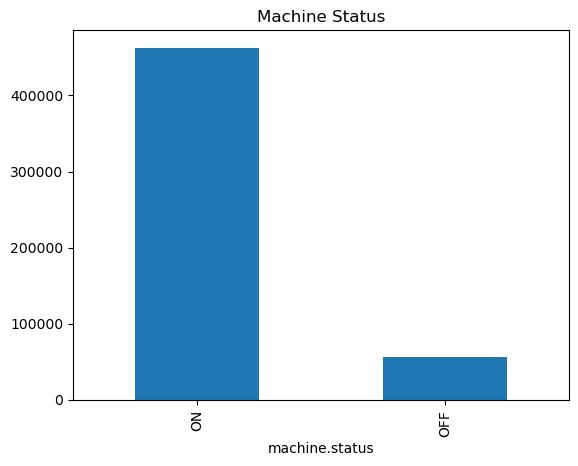

In [15]:
df["machine.status"].value_counts().plot(kind="bar")
plt.title("Machine Status")
plt.show()

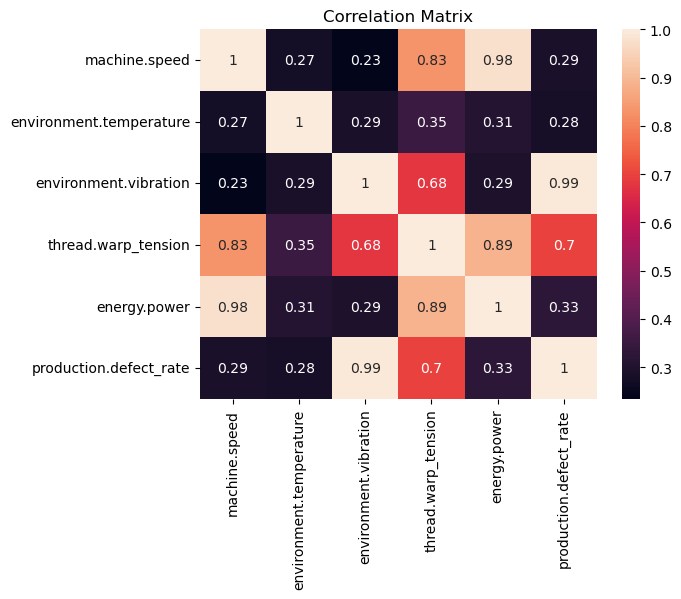

In [16]:
import seaborn as sns

cols = [
    "machine.speed",
    "environment.temperature",
    "environment.vibration",
    "thread.warp_tension",
    "energy.power",
    "production.defect_rate"
]

sns.heatmap(df_sample[cols].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

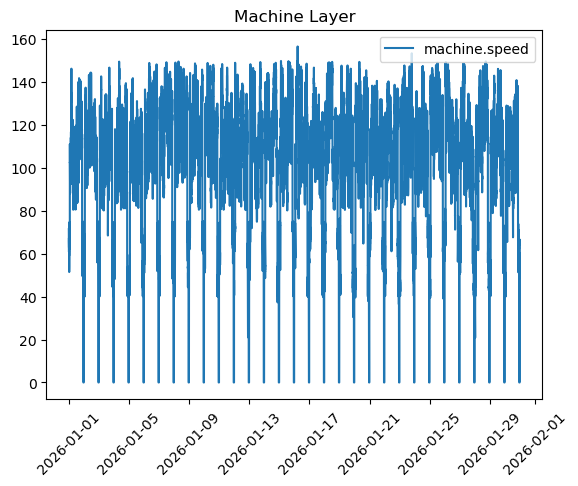

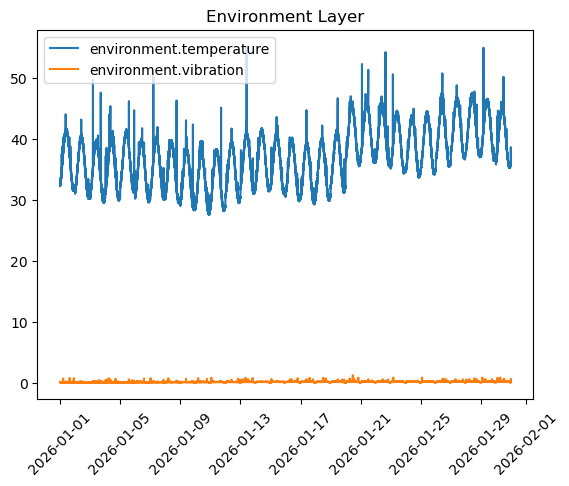

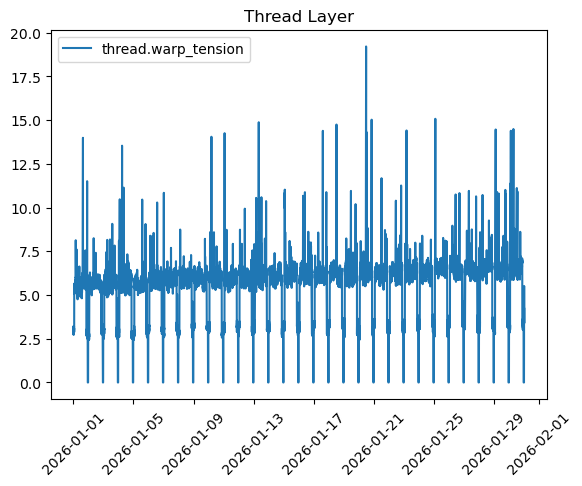

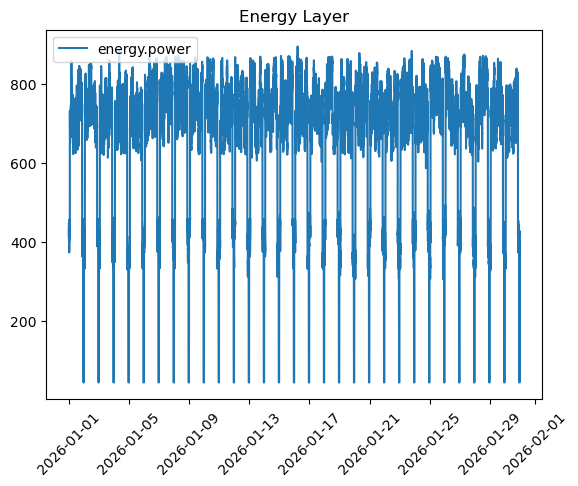

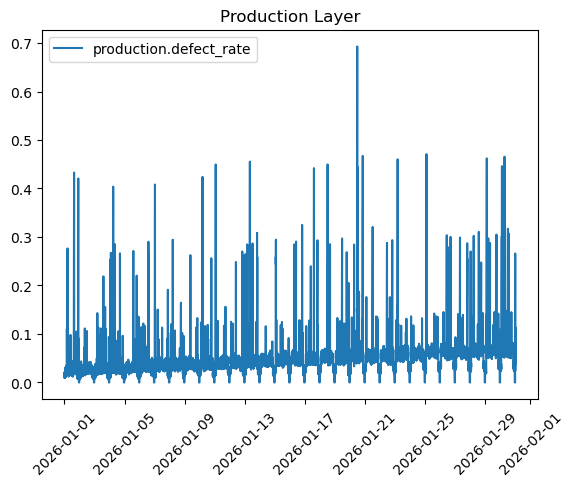

In [17]:
layers = {
    "Machine": ["machine.speed"],
    "Environment": ["environment.temperature", "environment.vibration"],
    "Thread": ["thread.warp_tension"],
    "Energy": ["energy.power"],
    "Production": ["production.defect_rate"]
}

for layer, cols in layers.items():
    plt.figure()
    for col in cols:
        plt.plot(df_resampled["timestamp"], df_resampled[col], label=col)
    plt.title(layer + " Layer")
    plt.legend()
    plt.xticks(rotation=45)
    plt.show()

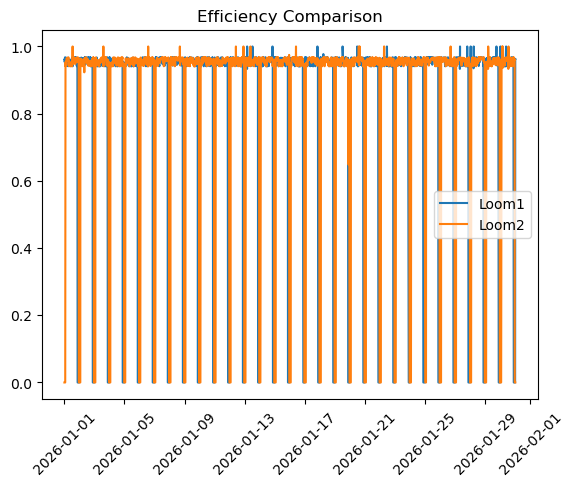

In [18]:
plt.figure()
plt.plot(loom1["timestamp"], loom1["production.efficiency"], label="Loom1")
plt.plot(loom2["timestamp"], loom2["production.efficiency"], label="Loom2")
plt.title("Efficiency Comparison")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [ ]:
#THREAD POSITION AND MATRIX 

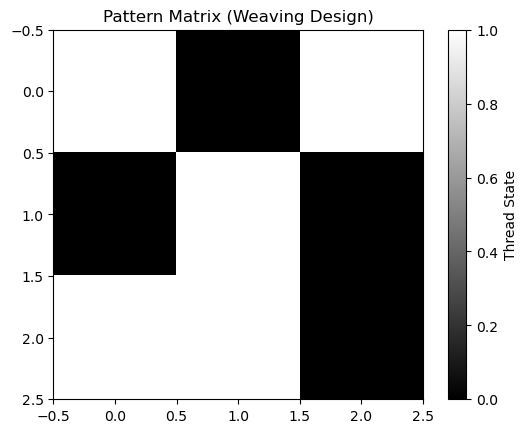

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Example matrix from your data
matrix = [[1,0,1],
          [0,1,0],
          [1,1,0]]

matrix = np.array(matrix)

plt.imshow(matrix, cmap="gray")
plt.title("Pattern Matrix (Weaving Design)")
plt.colorbar(label="Thread State")
plt.show()

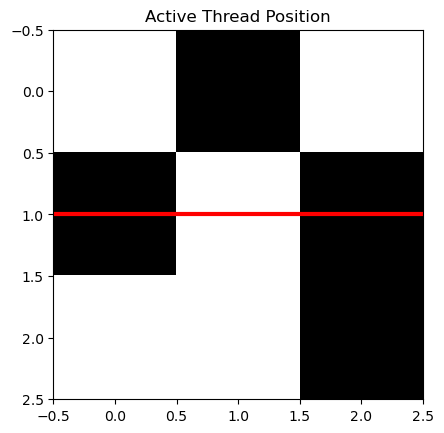

In [21]:
thread_pos = 1  # from your dataset

plt.imshow(matrix, cmap="gray")

# highlight current row
plt.axhline(y=thread_pos, color='red', linewidth=3)

plt.title("Active Thread Position")
plt.show()

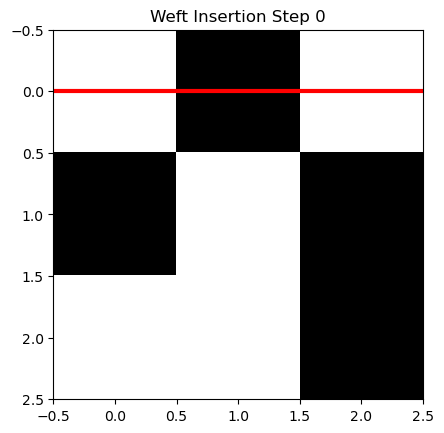

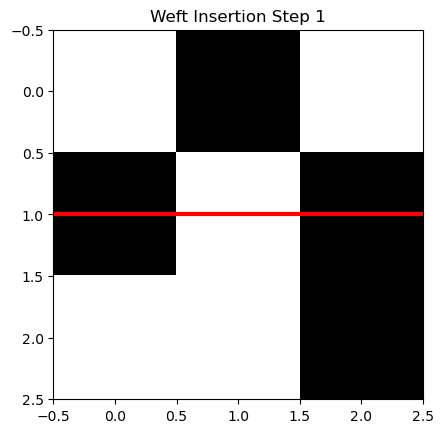

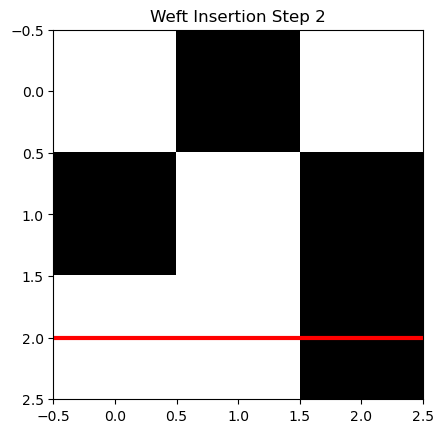

In [22]:
for i in range(len(matrix)):
    plt.figure()
    plt.imshow(matrix, cmap="gray")
    plt.axhline(y=i, color='red', linewidth=3)
    plt.title(f"Weft Insertion Step {i}")
    plt.show()

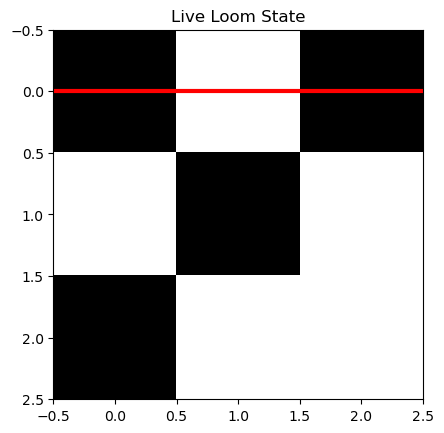

In [26]:
# pick one row from dataframe
row = df.iloc[223]

matrix = np.array(row["process.pattern_matrix"])
thread_pos = row["process.thread_position"]

plt.imshow(matrix, cmap="gray")
plt.axhline(y=thread_pos, color='red', linewidth=3)
plt.title("Live Loom State")
plt.show()

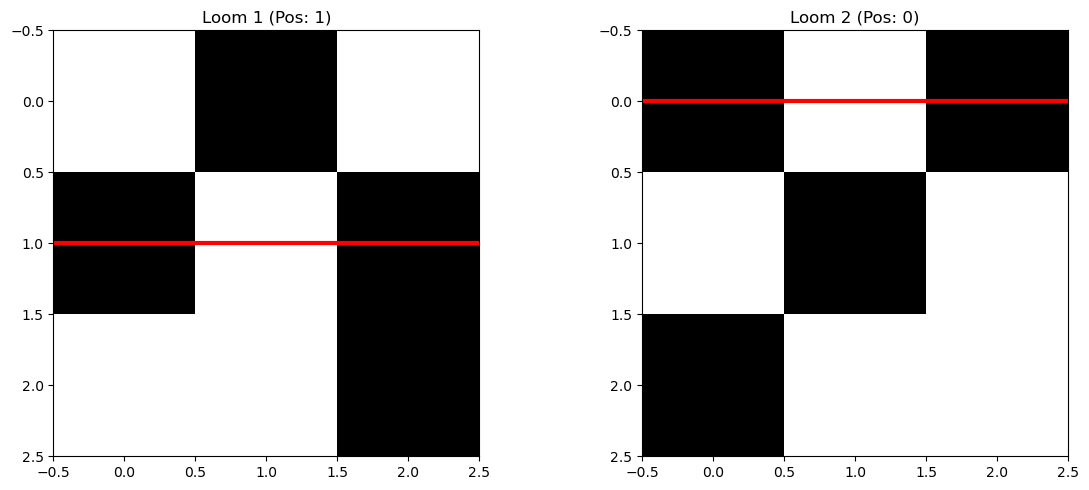

In [35]:
row1 = df[df["device_id"]=="loom_01"].iloc[258]
row2 = df[df["device_id"]=="loom_02"].iloc[2390]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Loom 1 Configuration ---
axes[0].imshow(row1["process.pattern_matrix"], cmap="gray")
axes[0].axhline(y=row1["process.thread_position"], color='red', linewidth=3)
axes[0].set_title(f"Loom 1 (Pos: {row1['process.thread_position']})")

# --- Loom 2 Configuration ---
axes[1].imshow(row2["process.pattern_matrix"], cmap="gray")
axes[1].axhline(y=row2["process.thread_position"], color='red', linewidth=3)
axes[1].set_title(f"Loom 2 (Pos: {row2['process.thread_position']})")

plt.tight_layout()
plt.show()

In [40]:
import json

with open("final_dataset_fixed.json") as f:
    data = [json.loads(line) for line in f]

with open("final_dataset_view.json", "w") as f:
    json.dump(data, f, indent=2)

print("✅ Viewable JSON created")

✅ Viewable JSON created


In [ ]:
#THREAD CHARECTERISTICS 

In [48]:
import pandas as pd

df = pd.read_json("final_dataset_fixed.json", lines=True)

print("Shape:", df.shape)
df.head()

Shape: (518400, 11)


,device_id,timestamp,machine,environment,fault,process,thread,energy,control,production,fault_detail
0,loom_01,2026-01-01 00:00:00+00:00,"{'status': 'ON', 'speed': 134, 'cycles': 1, 's...","{'temperature': 32.31, 'humidity': 66.92, 'vib...","{'thread_break': False, 'overheat': False, 'mo...","{'pattern_id': 'p001', 'pattern_matrix': [[1, ...","{'warp_tension': 6.166, 'weft_tension': 5.86, ...","{'voltage': 218.21, 'current': 3.733, 'power':...","{'target_speed': 139, 'speed_error': -5, 'mode...","{'defect_rate': 0.0358, 'quality': 'B', 'effic...","{'cause': None, 'severity': 'none'}"
1,loom_02,2026-01-01 00:00:00+00:00,"{'status': 'OFF', 'speed': 0, 'cycles': 0, 'sa...","{'temperature': 32.77, 'humidity': 67.78, 'vib...","{'thread_break': False, 'overheat': False, 'mo...","{'pattern_id': 'p002', 'pattern_matrix': [[0, ...","{'warp_tension': 0.0, 'weft_tension': 0.0, 'ya...","{'voltage': 220.0, 'current': 0.2, 'power': 44.0}","{'target_speed': 0, 'speed_error': 0, 'mode': ...","{'defect_rate': 0.0, 'quality': 'N/A', 'effici...","{'cause': None, 'severity': 'none'}"
2,loom_01,2026-01-01 00:00:10+00:00,"{'status': 'ON', 'speed': 134, 'cycles': 2, 's...","{'temperature': 32.47, 'humidity': 69.08, 'vib...","{'thread_break': False, 'overheat': False, 'mo...","{'pattern_id': 'p001', 'pattern_matrix': [[1, ...","{'warp_tension': 5.75, 'weft_tension': 5.341, ...","{'voltage': 218.21, 'current': 3.733, 'power':...","{'target_speed': 139, 'speed_error': -5, 'mode...","{'defect_rate': 0.0158, 'quality': 'A', 'effic...","{'cause': None, 'severity': 'none'}"
3,loom_02,2026-01-01 00:00:10+00:00,"{'status': 'OFF', 'speed': 0, 'cycles': 0, 'sa...","{'temperature': 32.75, 'humidity': 69.12, 'vib...","{'thread_break': False, 'overheat': False, 'mo...","{'pattern_id': 'p002', 'pattern_matrix': [[0, ...","{'warp_tension': 0.0, 'weft_tension': 0.0, 'ya...","{'voltage': 220.0, 'current': 0.2, 'power': 44.0}","{'target_speed': 0, 'speed_error': 0, 'mode': ...","{'defect_rate': 0.0, 'quality': 'N/A', 'effici...","{'cause': None, 'severity': 'none'}"
4,loom_01,2026-01-01 00:00:20+00:00,"{'status': 'ON', 'speed': 134, 'cycles': 3, 's...","{'temperature': 31.62, 'humidity': 67.28, 'vib...","{'thread_break': False, 'overheat': False, 'mo...","{'pattern_id': 'p001', 'pattern_matrix': [[1, ...","{'warp_tension': 5.956, 'weft_tension': 5.595,...","{'voltage': 218.21, 'current': 3.733, 'power':...","{'target_speed': 139, 'speed_error': -5, 'mode...","{'defect_rate': 0.025400000000000002, 'quality...","{'cause': None, 'severity': 'none'}"


In [49]:
import pandas as pd

df = pd.read_json("final_dataset_fixed.json", lines=True)

# flatten properly
df_flat = pd.json_normalize(df.to_dict(orient="records"))

print("Shape:", df_flat.shape)
df_flat.head()

Shape: (518400, 31)


,device_id,timestamp,machine.status,machine.speed,machine.cycles,machine.saree_count,environment.temperature,environment.humidity,environment.vibration,fault.thread_break,...,energy.current,energy.power,control.target_speed,control.speed_error,control.mode,production.defect_rate,production.quality,production.efficiency,fault_detail.cause,fault_detail.severity
0,loom_01,2026-01-01 00:00:00+00:00,ON,134,1,0,32.31,66.92,0.0646,False,...,3.733,814.66,139,-5,AUTO,0.0358,B,0.964,None,none
1,loom_02,2026-01-01 00:00:00+00:00,OFF,0,0,0,32.77,67.78,0.0098,False,...,0.200,44.00,0,0,OFF,0.0000,N/A,0.000,None,none
2,loom_01,2026-01-01 00:00:10+00:00,ON,134,2,0,32.47,69.08,0.0301,False,...,3.733,814.66,139,-5,AUTO,0.0158,A,0.964,None,none
3,loom_02,2026-01-01 00:00:10+00:00,OFF,0,0,0,32.75,69.12,0.0100,False,...,0.200,44.00,0,0,OFF,0.0000,N/A,0.000,None,none
4,loom_01,2026-01-01 00:00:20+00:00,ON,134,3,0,31.62,67.28,0.0465,False,...,3.733,814.66,139,-5,AUTO,0.0254,B,0.964,None,none


In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sample for performance
df_sample = df_flat.sample(20000, random_state=42)

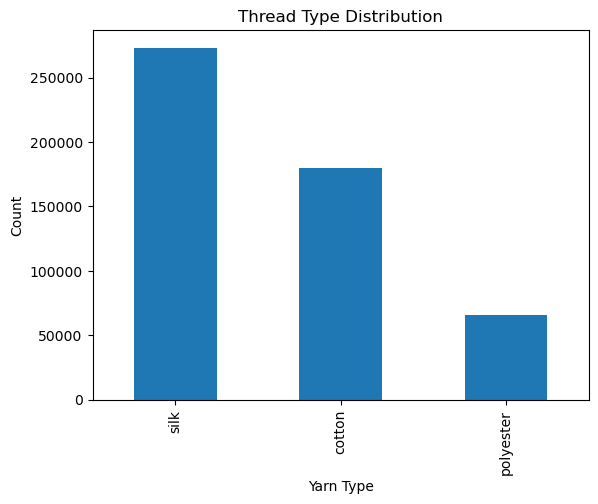

In [51]:
df_flat["thread.yarn_type"].value_counts().plot(kind="bar")
plt.title("Thread Type Distribution")
plt.xlabel("Yarn Type")
plt.ylabel("Count")
plt.show()

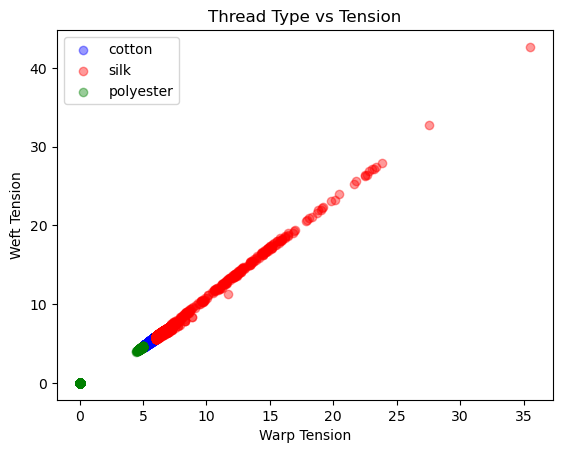

In [52]:
colors = {"cotton": "blue", "silk": "red", "polyester": "green"}

plt.figure()

for t, c in colors.items():
    subset = df_sample[df_sample["thread.yarn_type"] == t]
    
    if len(subset) > 0:
        plt.scatter(subset["thread.warp_tension"],
                    subset["thread.weft_tension"],
                    color=c, label=t, alpha=0.4)

plt.xlabel("Warp Tension")
plt.ylabel("Weft Tension")
plt.title("Thread Type vs Tension")
plt.legend()
plt.show()

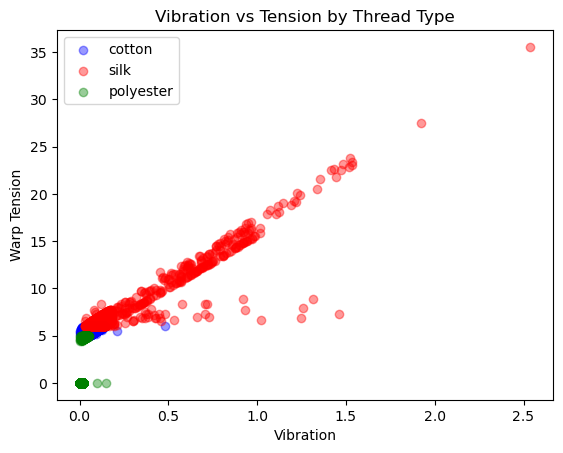

In [53]:
plt.figure()

for t, c in colors.items():
    subset = df_sample[df_sample["thread.yarn_type"] == t]
    
    plt.scatter(subset["environment.vibration"],
                subset["thread.warp_tension"],
                color=c, label=t, alpha=0.4)

plt.xlabel("Vibration")
plt.ylabel("Warp Tension")
plt.title("Vibration vs Tension by Thread Type")
plt.legend()
plt.show()

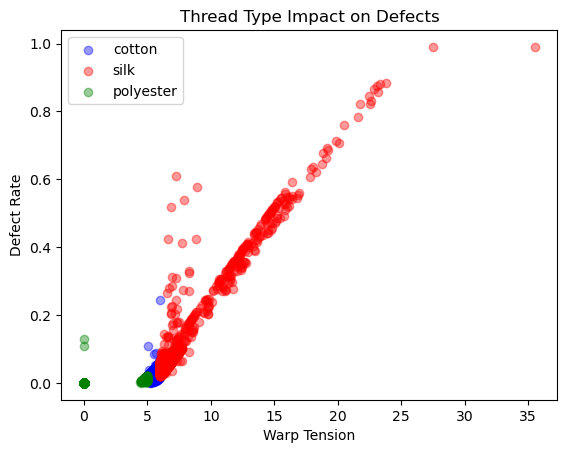

In [54]:
plt.figure()

for t, c in colors.items():
    subset = df_sample[df_sample["thread.yarn_type"] == t]
    
    plt.scatter(subset["thread.warp_tension"],
                subset["production.defect_rate"],
                color=c, label=t, alpha=0.4)

plt.xlabel("Warp Tension")
plt.ylabel("Defect Rate")
plt.title("Thread Type Impact on Defects")
plt.legend()
plt.show()

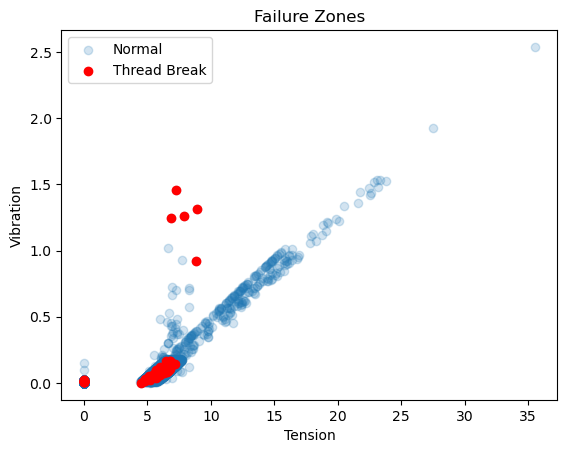

In [55]:
faults = df_sample[df_sample["fault.thread_break"] == True]

plt.figure()

plt.scatter(df_sample["thread.warp_tension"],
            df_sample["environment.vibration"],
            alpha=0.2, label="Normal")

plt.scatter(faults["thread.warp_tension"],
            faults["environment.vibration"],
            color="red", label="Thread Break")

plt.xlabel("Tension")
plt.ylabel("Vibration")
plt.title("Failure Zones")
plt.legend()
plt.show()

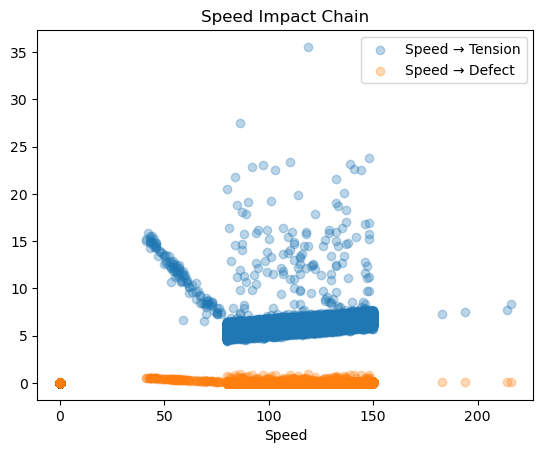

In [56]:
plt.figure()

plt.scatter(df_sample["machine.speed"],
            df_sample["thread.warp_tension"],
            alpha=0.3, label="Speed → Tension")

plt.scatter(df_sample["machine.speed"],
            df_sample["production.defect_rate"],
            alpha=0.3, label="Speed → Defect")

plt.xlabel("Speed")
plt.title("Speed Impact Chain")
plt.legend()
plt.show()

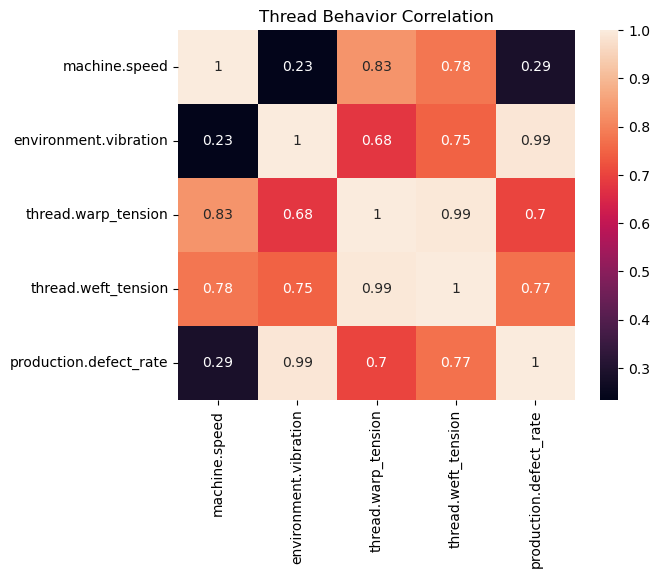

In [57]:
cols = [
    "machine.speed",
    "environment.vibration",
    "thread.warp_tension",
    "thread.weft_tension",
    "production.defect_rate"
]

sns.heatmap(df_sample[cols].corr(), annot=True)
plt.title("Thread Behavior Correlation")
plt.show()

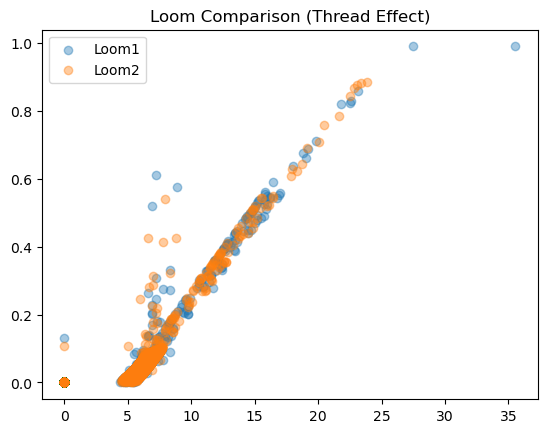

In [58]:
loom1 = df_sample[df_sample["device_id"] == "loom_01"]
loom2 = df_sample[df_sample["device_id"] == "loom_02"]

plt.figure()

plt.scatter(loom1["thread.warp_tension"],
            loom1["production.defect_rate"],
            label="Loom1", alpha=0.4)

plt.scatter(loom2["thread.warp_tension"],
            loom2["production.defect_rate"],
            label="Loom2", alpha=0.4)

plt.legend()
plt.title("Loom Comparison (Thread Effect)")
plt.show()